In [13]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import matthews_corrcoef

In [16]:
def load_metrics_and_preds(base_dir, pred_filename, metrics_json=None):
    """
    Завантажує передбачення та обчислює MCC.

    Якщо вказано metrics_json — бере MCC з нього (для моделей з власним JSON,
    де поріг вже оптимізований під час тренування).
    Інакше — знаходить оптимальний поріг за MCC безпосередньо з CSV
    (для окремих експертів на кшталт KNN, у яких немає власного JSON).
    """
    df = pd.read_csv(os.path.join(base_dir, pred_filename))

    if metrics_json is not None:
        with open(os.path.join(base_dir, metrics_json), 'r') as f:
            final_mcc = json.load(f)['mcc']
    else:
        # Читаємо MCC, збережений під час тренування з tune-split порогом
        final_mcc = df['mcc'].iloc[0]

    return df, final_mcc

Графік успішно збережено у ensemble_comparison_roc_mcc.png


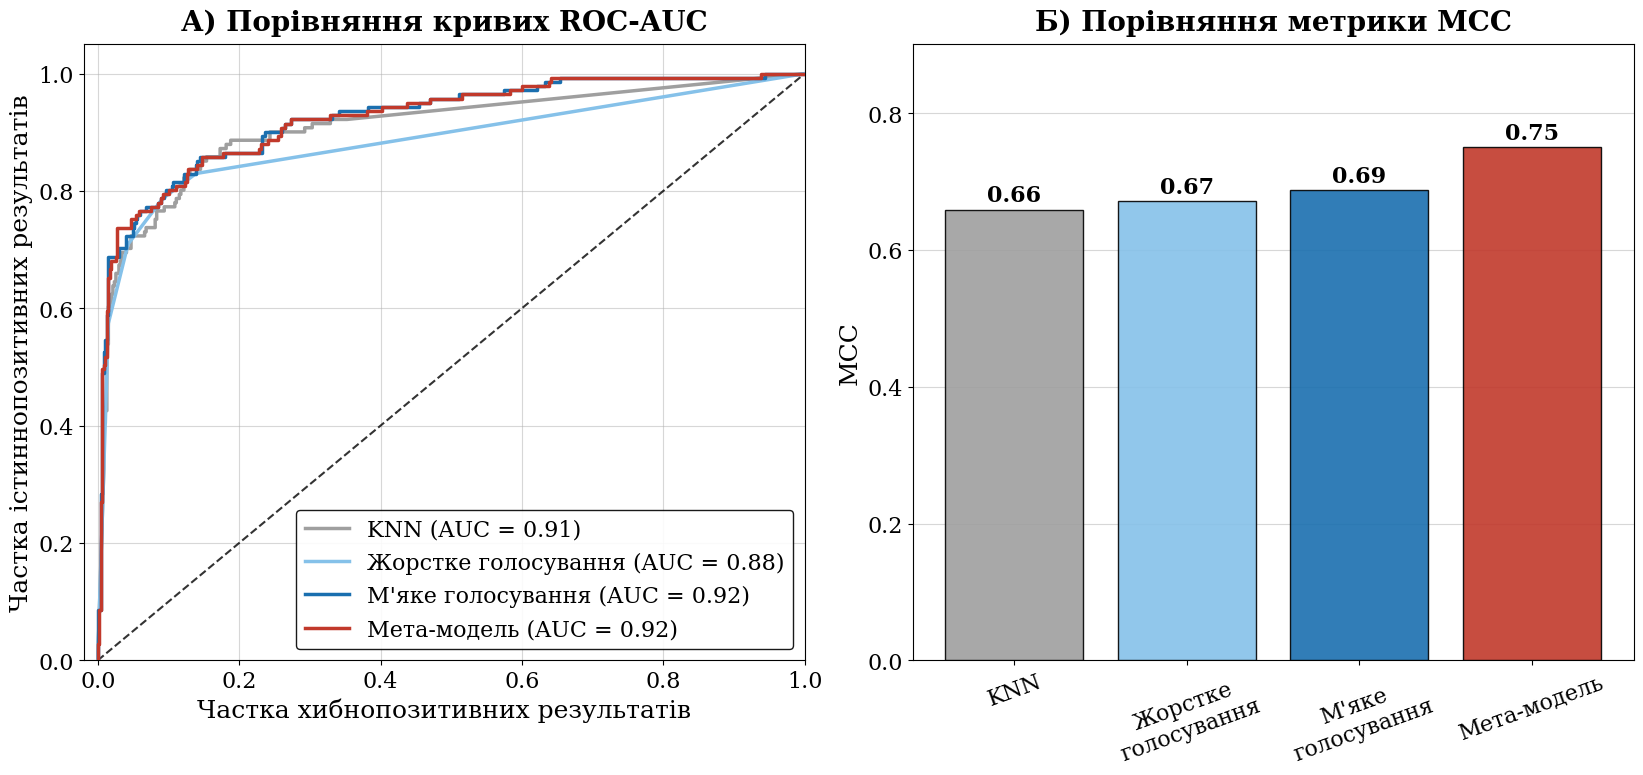

In [31]:
def plot_ensemble_comparison():
    # =======================================================
    # 1. SETUP & STYLING (Matched exactly to UMAP script)
    # =======================================================
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
    plt.rcParams['axes.unicode_minus'] = False
    
    """# Витягуємо кольори з палітри RdBu_r
    cmap = plt.get_cmap('RdBu_r')
    color_meta = cmap(0.10)  
    color_soft = cmap(0.90)   
    color_knn = cmap(0.75)
    color_hard = cmap(0.25) """ 

    color_knn  = "#9F9F9F"  # без змін
    color_hard = "#85C1E9"  # світліший блакитний — слабший метод
    color_soft = "#1A6FAF"  # насичений синій — сильніший метод  
    color_meta = "#C1392B"  # без змін  

    models_info = {
            "KNN": {
                "dir": "../models/meta_model_y_true/",
                "pred_file": "test_preds_knn.csv",
                "metrics_json": None,
                "color": color_knn, "ls": "-"
            },
            "Жорстке\nголосування": {
                "dir": "../models/hard_model_y_true/",
                "pred_file": "test_preds_hard_voting.csv",
                "metrics_json": "test_metrics.json",
                "color": color_hard, "ls": "-"
            },
            "М'яке\nголосування": {
                "dir": "../models/avg_model_y_true/",
                "pred_file": "test_preds_averaging.csv",
                "metrics_json": "test_metrics.json",
                "color": color_soft, "ls": "-"
            },
            "Мета-модель": {
                "dir": "../models/meta_model_y_true/",
                "pred_file": "test_preds_meta.csv",
                "metrics_json": "test_metrics.json",
                "color": color_meta, "ls": "-"
            }
        }

    # Макет, що відповідає чистому підходу GridSpec
    fig = plt.figure(figsize=(20, 8))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.15)

    ax_roc = plt.subplot(gs[0])
    ax_mcc = plt.subplot(gs[1])
    
    mcc_scores = {}

    # =======================================================
    # 2. PLOT ROC-AUC (Ліва панель)
    # =======================================================
    for name, info in models_info.items():
        # Для легенди прибираємо перенесення рядка, щоб виглядало охайно
        legend_name = name.replace('\n', ' ') 
        try:
            df, final_mcc = load_metrics_and_preds(
                info['dir'], info['pred_file'], info.get('metrics_json')
            )
            mcc_scores[name] = final_mcc
            
            # Розрахунок ROC-кривої
            fpr, tpr, _ = roc_curve(df['y_true'], df['y_prob'])
            roc_auc = auc(fpr, tpr)
            
            # Побудова графіка з zorder=3 (поверх сітки)
            ax_roc.plot(fpr, tpr, color=info['color'], linestyle=info['ls'], linewidth=2.5,
                        label=f'{legend_name} (AUC = {roc_auc:.2f})', zorder=3)
        except FileNotFoundError:
            print(f"Увага: Дані для {legend_name} не знайдено. Пропускаємо.")

    # Діагональна лінія випадкового вгадування
    ax_roc.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5, alpha=0.8, zorder=2)
    
    # Сітка та підписи
    ax_roc.grid(True, linestyle='-', alpha=0.5, zorder=1)
    ax_roc.set_xlim([-0.02, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    
    ax_roc.set_xlabel('Частка хибнопозитивних результатів', fontsize=18)
    ax_roc.set_ylabel('Частка істиннопозитивних результатів', fontsize=18)
    ax_roc.set_title('А) Порівняння кривих ROC-AUC', fontsize=20, fontweight='bold', pad=10)
    ax_roc.tick_params(axis='both', labelsize=16)
    
    # Стиль легенди
    ax_roc.legend(loc="lower right", fontsize=16, framealpha=0.9, edgecolor='black')

    # =======================================================
    # 3. PLOT MCC BAR CHART (Права панель)
    # =======================================================
    if mcc_scores:
        names = list(mcc_scores.keys())
        scores = list(mcc_scores.values())
        colors = [models_info[n]['color'] for n in names]
        
        # Побудова стовпчиків з чорними краями
        bars = ax_mcc.bar(names, scores, color=colors, edgecolor='black', linewidth=1.0, zorder=3, alpha=0.9)
        
        # Додавання значень над стовпчиками
        for bar in bars:
            height = bar.get_height()
            ax_mcc.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                        f'{height:.2}', ha='center', va='bottom', 
                        fontsize=16, fontweight='bold', zorder=4)

        # Сітка та підписи
        ax_mcc.grid(True, axis='y', linestyle='-', alpha=0.5, zorder=1)
        ax_mcc.set_ylabel('MCC', fontsize=18)
        ax_mcc.set_title('Б) Порівняння метрики MCC', fontsize=20, fontweight='bold', pad=10)
        ax_mcc.set_ylim([0, max(scores) * 1.2]) # Запас місця для тексту зверху
        
        ax_mcc.tick_params(axis='y', labelsize=16)
        ax_mcc.tick_params(axis='x', labelsize=16, rotation=20)

    # =======================================================
    # 4. ФІНАЛЬНІ НАЛАШТУВАННЯ МАКЕТУ
    # =======================================================
    """fig.suptitle('Порівняння ефективності ансамблів: Стекінг проти базових методів голосування', 
                 fontsize=18, 
                 fontweight='bold', 
                 y=0.98)"""

    # Макет узгоджений з попереднім скриптом
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    save_path = "ensemble_comparison_roc_mcc.png"
    plt.savefig(save_path, dpi=400, bbox_inches='tight')
    print(f"Графік успішно збережено у {save_path}")
    plt.show()

plot_ensemble_comparison()